# Project : Sentiment Analysis of Movie Reviews using Artificial Intelligence

## Load Dataset

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")

# Display first 5 rows
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Cleaning & Preprocessing

“In data preprocessing, the textual reviews were cleaned by converting to lowercase, removing HTML tags, punctuation, and unnecessary characters. This step improves the quality of text data and helps the machine learning model to learn effectively.”

### Step 2.1: Import Required Libraries

In [3]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to C:\Users\Rizwan
[nltk_data]     computers\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Step 2.2: Create Cleaning Function

In [4]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


### Step 2.3: Apply Cleaning on Dataset

In [5]:
df['clean_review'] = df['review'].apply(clean_text)

df.head()


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


## Stopword Removal & Final Text Preparation

“After cleaning the text, stopwords were removed to eliminate unnecessary words that do not contribute to sentiment. This helps in reducing dimensionality and improving the performance of the machine learning model.”

### Step 3.1 – Create Stopword List

In [6]:
stop_words = set(stopwords.words('english'))


### Step 3.2 – Create Function to Remove Stopwords

In [7]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)


### Step 3.3 – Apply Stopword Removal

In [8]:
df['final_review'] = df['clean_review'].apply(remove_stopwords)

df.head()


,review,sentiment,clean_review,final_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


## Convert Text into Numbers (TF-IDF Vectorization)

“TF-IDF vectorization was used to convert textual data into numerical feature vectors. The sentiment labels were encoded into binary form for classification.”

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['final_review']).toarray()


### Convert Target Column

In [10]:
y = df['sentiment'].map({'positive':1, 'negative':0})


## Train Test Split

“The dataset was split into training and testing sets in an 80:20 ratio to evaluate model performance.”

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training (Naive Bayes)

“Naive Bayes classifier was selected due to its efficiency and effectiveness in text classification problems.”

In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train);


## Prediction

In [13]:
y_pred = model.predict(X_test)


## Model Evaluation (Testing Section)

“The model performance was evaluated using accuracy, precision, recall, and F1-score. The confusion matrix was used to visualize classification results.”

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8499

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### Confusion Matrix

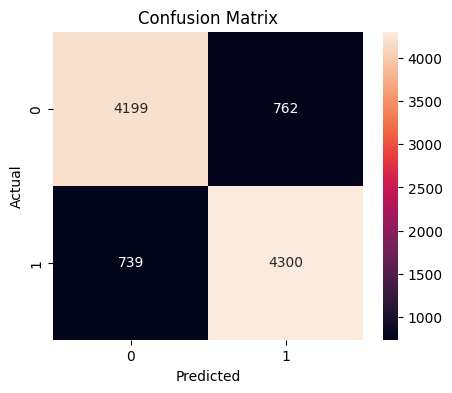

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Testing on New Custom Input

In [16]:
def predict_sentiment(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    text_vector = vectorizer.transform([text]).toarray()
    result = model.predict(text_vector)
    return "Positive" if result[0] == 1 else "Negative"

# Test
print(predict_sentiment("This movie was absolutely fantastic and inspiring"))
print(predict_sentiment("I hated this movie, it was boring and waste of time"))


Positive
Negative


## Neural Network Model

## Import Neural Network Libraries

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


## Build Neural Network Model

In [22]:
nn_model = Sequential()

# Input layer + first hidden layer
nn_model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Dropout layer
nn_model.add(Dropout(0.3))

# Second hidden layer
nn_model.add(Dense(64, activation='relu'))

# Output layer
nn_model.add(Dense(1, activation='sigmoid'))


C:\Users\Rizwan computers\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the Model

In [23]:
nn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


## Train Neural Network

In [24]:
history = nn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8630 - loss: 0.3270 - val_accuracy: 0.8852 - val_loss: 0.2709
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9085 - loss: 0.2260 - val_accuracy: 0.8824 - val_loss: 0.2782
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9346 - loss: 0.1723 - val_accuracy: 0.8793 - val_loss: 0.2979
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9664 - loss: 0.1035 - val_accuracy: 0.8718 - val_loss: 0.3646
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9856 - loss: 0.0502 - val_accuracy: 0.8732 - val_loss: 0.4649


## Evaluate Neural Network

In [25]:
loss, accuracy = nn_model.evaluate(X_test, y_test)

print("Neural Network Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8732 - loss: 0.4649
Neural Network Accuracy: 0.873199999332428


## Predict Using Neural Network

In [26]:
nn_predictions = nn_model.predict(X_test)

# Convert probabilities to 0 or 1
nn_predictions = (nn_predictions > 0.5).astype(int)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Confusion Matrix for Neural Network

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

print("Neural Network Classification Report:\n", classification_report(y_test, nn_predictions))


Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87      4961
           1       0.86      0.90      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

